In [ ]:
!pip install pydicom -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.3 MB/s eta 0:00:00


In [ ]:
# =========================
# 1. Setup
# =========================

import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from tqdm.auto import tqdm


## نسخه EfficientNet-B0

در این نسخه، مدل قبلی با **EfficientNet-B0** جایگزین شده است. ساختار Dataset، DataLoader، loss، training loop و evaluation حفظ شده‌اند. ورودی مدل برای تصاویر پزشکی خاکستری **۱ کاناله** تنظیم شده و خروجی مدل برای classification دودویی `pneumonia / normal` است.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!find /content/drive -type d -name "kaggle-pneumonia"

^C


In [ ]:
!ls /content/drive

MyDrive


In [ ]:
!ls /content/drive/MyDrive

 1_2.png		       River_Tehran_shp.prj
 cat_to_name_1.json	       River_Tehran_shp.shp
 cat_to_name.json	       River_Tehran_shp.shx
 checkpoint.pth		       rose_1.jpg
'Colab Notebooks'	       slope.tif
 colab-projects		       srtm_90.tif
 Data			       test
 dicom_dir		       test_fitz
'download (1).png'	       test_pad
 download.png		       test_pad_1
 drylands.tif		       test_ted
 EarthEngine		       test_ted_1
 FalseColor_Landsat7_PNG.tif   test_ted_2
 FalseColor_Landsat7.tif       train
 hough_Isfahan.tif	       train_pad
 ISIC_0000001.jpg	       train_pad_1
 landcover_iran.tif	       train_ted
 landscape_1.jpeg	      'train_ted _1'
 MRHead.nii.gz		       train_ted_2
 ndvi_nxzxb.tif		       train_test
 NkYsm.png		       UTKFace.zip
 paper_dataset.zip	       uw-madison-gi-tract-image-segmentation.zip
 PAT_15_1001_749.png	       valid
 PAT_204_310_975.png	       valid_pad
 processed		       valid_pad_1
 River_Tehran.kml	       valid_ted
 River_Tehran_shp.cpg	       valid_ted_1
 Rive

In [ ]:
# =========================
# 2. Paths
# =========================
ROOT = "/content/drive/MyDrive/Data/kaggle-pneumonia"

IMAGE_DIR = Path(ROOT) / "stage_2_train_images"
CSV_PATH = Path(ROOT) / "stage_2_train_labels.csv"

labels = pd.read_csv(CSV_PATH)



In [ ]:
print(labels.head())
print(labels["Target"].value_counts())

                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN    NaN    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1
Target
0    20672
1     9555
Name: count, dtype: int64


In [ ]:
# =========================
# 3. Remove duplicate labels
# =========================
# چون بعضی بیمارها چند bounding box دارند، فقط یک label نهایی می‌گیریم
labels_binary = labels.groupby("patientId")["Target"].max().reset_index()

train_df, val_df = train_test_split(
    labels_binary,
    test_size=0.2,
    random_state=42,
    stratify=labels_binary["Target"]
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print(train_df["Target"].value_counts())
print(val_df["Target"].value_counts())

Train: (21347, 2)
Val: (5337, 2)
Target
0    16537
1     4810
Name: count, dtype: int64
Target
0    4135
1    1202
Name: count, dtype: int64


In [ ]:
# =========================
# 4. Dataset class
# =========================
class PneumoniaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = self.df.loc[idx, "patientId"]
        label = self.df.loc[idx, "Target"]

        dcm_path = self.image_dir / f"{patient_id}.dcm"
        dcm = pydicom.dcmread(str(dcm_path))
        img = dcm.pixel_array.astype(np.float32)

        img = cv2.resize(img, (224, 224))
        img = img / img.max()

        img = np.expand_dims(img, axis=0)
        img = torch.tensor(img, dtype=torch.float32)

        label = torch.tensor(label, dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
# =========================
# 5. Data augmentation + DataLoaders
# =========================
from torch.utils.data import DataLoader
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
])

val_transform = None

FAST_DEV_RUN = True
FAST_TRAIN_SAMPLES = 2000
FAST_VAL_SAMPLES = 500

if FAST_DEV_RUN:
    train_df_used = (
        train_df
        .groupby("Target", group_keys=False)
        .apply(lambda x: x.sample(
            n=min(len(x), FAST_TRAIN_SAMPLES // train_df["Target"].nunique()),
            random_state=42
        ))
        .reset_index(drop=True)
    )

    val_df_used = (
        val_df
        .groupby("Target", group_keys=False)
        .apply(lambda x: x.sample(
            n=min(len(x), FAST_VAL_SAMPLES // val_df["Target"].nunique()),
            random_state=42
        ))
        .reset_index(drop=True)
    )

    print("FAST_DEV_RUN is ON")
    print("Train used:", train_df_used.shape)
    print(train_df_used["Target"].value_counts())
    print("Val used:", val_df_used.shape)
    print(val_df_used["Target"].value_counts())

else:
    train_df_used = train_df.reset_index(drop=True)
    val_df_used = val_df.reset_index(drop=True)

train_dataset = PneumoniaDataset(
    train_df_used,
    IMAGE_DIR,
    transform=train_transform
)

val_dataset = PneumoniaDataset(
    val_df_used,
    IMAGE_DIR,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


FAST_DEV_RUN is ON
Train used: (2000, 2)
Target
0    1000
1    1000
Name: count, dtype: int64
Val used: (500, 2)
Target
0    250
1    250
Name: count, dtype: int64
Train batches: 63
Val batches: 16


/tmp/ipykernel_1386/2318695938.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipykernel_1386/2318695938.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


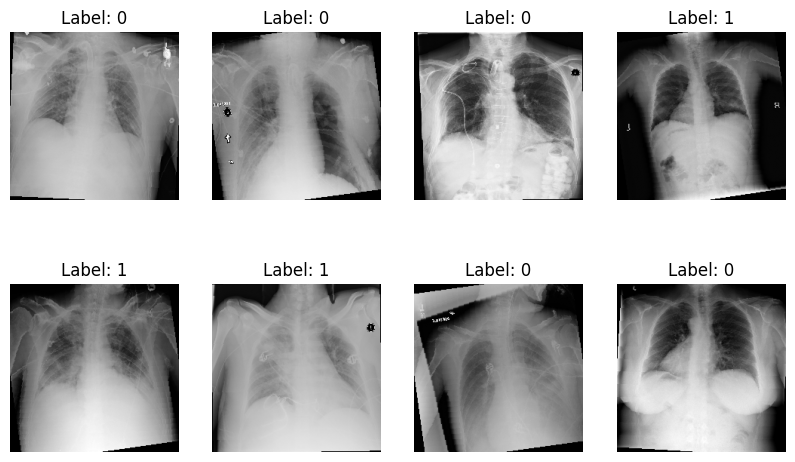

In [ ]:
# =========================
# 6. Show sample images
# =========================
imgs, lbls = next(iter(train_loader))

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imgs[i][0], cmap="gray")
    plt.title(f"Label: {int(lbls[i].item())}")
    plt.axis("off")
plt.show()

In [ ]:
# =========================
# 7. Model - EfficientNet-B0
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# EfficientNet-B0 pre-trained on ImageNet
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# تغییر ورودی از RGB سه‌کاناله به تصویر پزشکی خاکستری یک‌کاناله
old_conv = model.features[0][0]
model.features[0][0] = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

# میانگین گرفتن از وزن‌های سه کانال RGB برای ساخت وزن اولیه یک کاناله
with torch.no_grad():
    model.features[0][0].weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

# خروجی دودویی: pneumonia / normal
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)

model = model.to(device)
print("Model: EfficientNet-B0")


cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s]


Model: EfficientNet-B0


In [ ]:
# =========================
# 8. Loss and optimizer
# =========================
# وزن‌دهی کلاس مثبت برای کمک به عدم‌تعادل کلاس‌ها
num_pos = train_df_used["Target"].sum()
num_neg = len(train_df_used) - num_pos

pos_weight = torch.tensor([num_neg / max(num_pos, 1)], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer پیشنهادی برای EfficientNet
optimizer = torch.optim.AdamW(
    model.parameters(),
    #lr=1e-4,
    lr=5e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss: BCEWithLogitsLoss")
print("Optimizer: AdamW")
print("Learning rate: 5e-5")
print("Positive class weight:", pos_weight.item())


Loss: BCEWithLogitsLoss
Optimizer: AdamW
Learning rate: 1e-4
Positive class weight: 1.0


In [ ]:
# =========================
# 9. Training and validation functions with progress bars
# =========================
def train_one_epoch(model, loader, epoch=None, total_epochs=None):
    model.train()
    total_loss = 0.0

    desc = "Train"
    if epoch is not None and total_epochs is not None:
        desc = f"Train Epoch {epoch}/{total_epochs}"

    progress_bar = tqdm(loader, desc=desc, leave=True)

    for batch_idx, (images, labels) in enumerate(progress_bar, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        avg_loss = total_loss / batch_idx

        progress_bar.set_postfix({
            "batch_loss": f"{loss.item():.4f}",
            "avg_loss": f"{avg_loss:.4f}"
        })

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()

    all_labels = []
    all_probs = []
    total_loss = 0.0

    progress_bar = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(progress_bar, start=1):
            images = images.to(device, non_blocking=True)
            labels_gpu = labels.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels_gpu)

            probs = torch.sigmoid(outputs).cpu().numpy().flatten()

            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

            total_loss += loss.item()
            progress_bar.set_postfix({"avg_loss": f"{total_loss / batch_idx:.4f}"})

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    preds = (all_probs >= 0.5).astype(int)

    metrics = {
        "loss": total_loss / len(loader),
        "accuracy": accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall": recall_score(all_labels, preds, zero_division=0),
        "f1": f1_score(all_labels, preds, zero_division=0),
        "auc": roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else np.nan
    }

    return metrics


def sanity_check_one_batch(model, loader):
    """یک تست خیلی سریع برای اینکه مطمئن شویم دیتالودر، مدل، loss و backward سالم هستند."""
    model.train()
    images, labels = next(iter(loader))
    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True).unsqueeze(1)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    probs = torch.sigmoid(outputs).detach().cpu().numpy().flatten()
    print("Sanity check OK")
    print("images shape:", tuple(images.shape))
    print("outputs shape:", tuple(outputs.shape))
    print("loss:", float(loss.item()))
    print("first 5 probabilities:", probs[:5])


Sanity check OK
images shape: (32, 1, 224, 224)
outputs shape: (32, 1)
loss: 0.7099432945251465
first 5 probabilities: [0.50230783 0.5566261  0.5746628  0.44398034 0.40963408]


Train Epoch 1/5:   0%|          | 0/63 [00:00<?, ?it/s]

Validation:   0%|          | 0/16 [00:00<?, ?it/s]


Epoch 1/5 finished in 51.53 min
Train Loss: 0.5736
Val Loss: 0.5271
Accuracy: 0.7640
Precision: 0.7000
Recall: 0.9240
F1-score: 0.7966
AUC: 0.8454
Best model saved.


Train Epoch 2/5:   0%|          | 0/63 [00:00<?, ?it/s]

...


Epoch 4/5 finished in 0.70 min
Train Loss: 0.4192
Val Loss: 0.4551
Accuracy: 0.7980
Precision: 0.8016
Recall: 0.7920
F1-score: 0.7968
AUC: 0.8655


Train Epoch 5/5:   0%|          | 0/63 [00:00<?, ?it/s]

Validation:   0%|          | 0/16 [00:00<?, ?it/s]


Epoch 5/5 finished in 0.70 min
Train Loss: 0.3784
Val Loss: 0.4981
Accuracy: 0.7900
Precision: 0.8085
Recall: 0.7600
F1-score: 0.7835
AUC: 0.8608


,epoch,train_loss,loss,accuracy,precision,recall,f1,auc,time_sec
0,1,0.573641,0.527117,0.764,0.700000,0.924,0.796552,0.845408,3091.860940
1,2,0.497670,0.444250,0.796,0.786822,0.812,0.799213,0.872352,42.777929
2,3,0.452457,0.458223,0.794,0.815451,0.760,0.786749,0.869264,42.236865
3,4,0.419221,0.455118,0.798,0.801619,0.792,0.796781,0.865472,42.104749
4,5,0.378428,0.498103,0.790,0.808511,0.760,0.783505,0.860768,42.001464


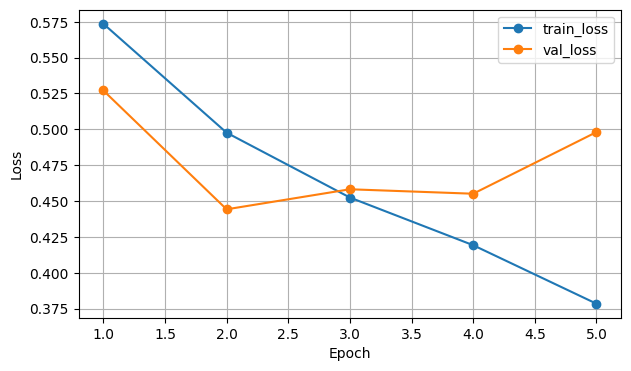

In [ ]:
# =========================
# 10. Train model
# =========================
# اول یک batch تست می‌کنیم تا سریع بفهمیم کل مسیر سالم است.
sanity_check_one_batch(model, train_loader)

EPOCHS = 15
best_auc = -1
history = []

save_path = "/content/drive/MyDrive/best_pneumonia_model_eff_1.pth"

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_loss = train_one_epoch(model, train_loader, epoch=epoch, total_epochs=EPOCHS)
    val_metrics = evaluate(model, val_loader)

    val_loss = val_metrics["loss"]      # این خط را اضافه کن
    scheduler.step(val_loss)

    elapsed = time.time() - start_time

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **val_metrics,
        "time_sec": elapsed
    }
    history.append(row)

    print(f"\nEpoch {epoch}/{EPOCHS} finished in {elapsed/60:.2f} min")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-score: {val_metrics['f1']:.4f}")
    print(f"AUC: {val_metrics['auc']:.4f}")

    current_auc = val_metrics["auc"]
    if not np.isnan(current_auc) and current_auc > best_auc:
        best_auc = current_auc
        torch.save(model.state_dict(), save_path)
        print("Best model saved.")

history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# =========================
# 11. Confusion matrix
# =========================
model.load_state_dict(torch.load("/content/drive/MyDrive/best_pneumonia_model.pth"))

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()

        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
preds = (all_probs >= 0.5).astype(int)

cm = confusion_matrix(all_labels, preds)
print(cm)

[[195  55]
 [ 47 203]]


In [ ]:
#cpu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.load_state_dict(
    torch.load("/content/drive/MyDrive/best_pneumonia_model.pth", map_location=device)
)
model.to(device)
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()

        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
preds = (all_probs >= 0.5).astype(int)

cm = confusion_matrix(all_labels, preds)
print(cm)

[[195  55]
 [ 47 203]]


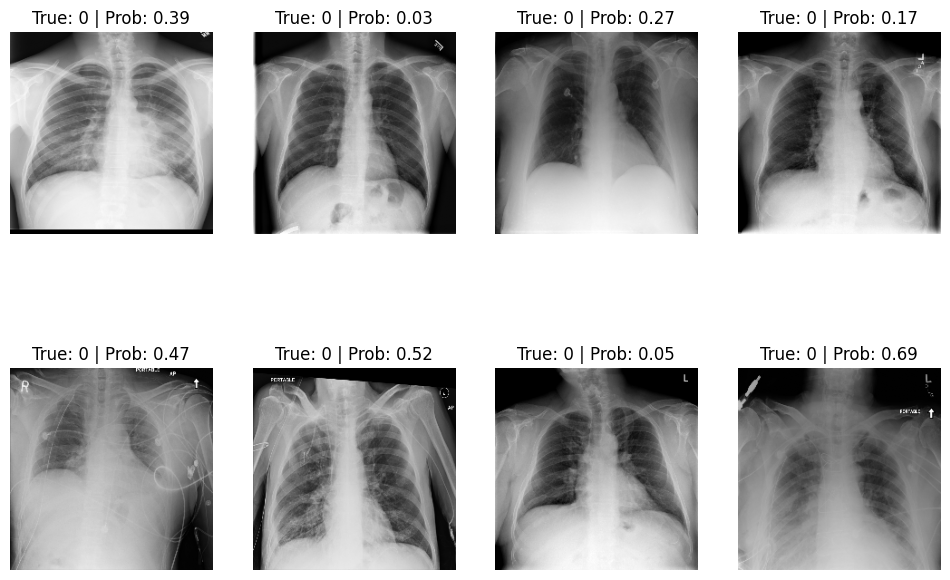

In [ ]:
# =========================
# 12. Show predictions
# =========================
imgs, lbls = next(iter(val_loader))

model.eval()
with torch.no_grad():
    outputs = model(imgs.to(device))
    probs = torch.sigmoid(outputs).cpu().numpy().flatten()

plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imgs[i][0], cmap="gray")
    plt.title(f"True: {int(lbls[i])} | Prob: {probs[i]:.2f}")
    plt.axis("off")
plt.show()